In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

if not os.path.exists("Figures"):
    os.makedirs("Figures")

try:
    df = pd.read_csv("breast_cancer_dataset.csv")
    print("Dataset Loaded Successfully")
except FileNotFoundError:
    print("breast_cancer_dataset.csv not found.")
    print("Loading sklearn dataset instead...\n")

    data = load_breast_cancer()

    df = pd.DataFrame(
        data.data,
        columns=data.feature_names
    )

    df["diagnosis"] = data.target

print("\nFirst Five Rows\n")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records :", df.duplicated().sum())

if "diagnosis" in df.columns:

    if df["diagnosis"].dtype == object:

        df["diagnosis"] = df["diagnosis"].map({
            "M": 1,
            "B": 0
        })

if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

print("\nDiagnosis Distribution\n")
print(df["diagnosis"].value_counts())

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nGenerating Correlation Heatmap...")

corr = df.corr()

plt.figure(figsize=(12,10))

plt.imshow(
    corr,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=6
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=6
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "Figures/correlation_heatmap.png",
    dpi=300
)

plt.close()

print("Saved -> Figures/correlation_heatmap.png")

print("\nGenerating Feature Distribution...")

selected_features = [
    X.columns[0],
    X.columns[1],
    X.columns[2],
    X.columns[3]
]

plt.figure(figsize=(10,8))

for i, feature in enumerate(selected_features):

    plt.subplot(2,2,i+1)

    plt.hist(
        df[feature],
        bins=20
    )

    plt.title(feature)

plt.tight_layout()

plt.savefig(
    "Figures/feature_distribution.png",
    dpi=300
)

plt.close()

print("Saved -> Figures/feature_distribution.png")

print("\nSummary Statistics\n")
print(df.describe())

print("\nPart 1 Completed Successfully.")

Dataset Loaded Successfully

First Five Rows

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_

ValueError: could not convert string to float: 'M'

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  texture_worst  perimeter_worst  area_worst  \
0         0.2419  ...          17.33           

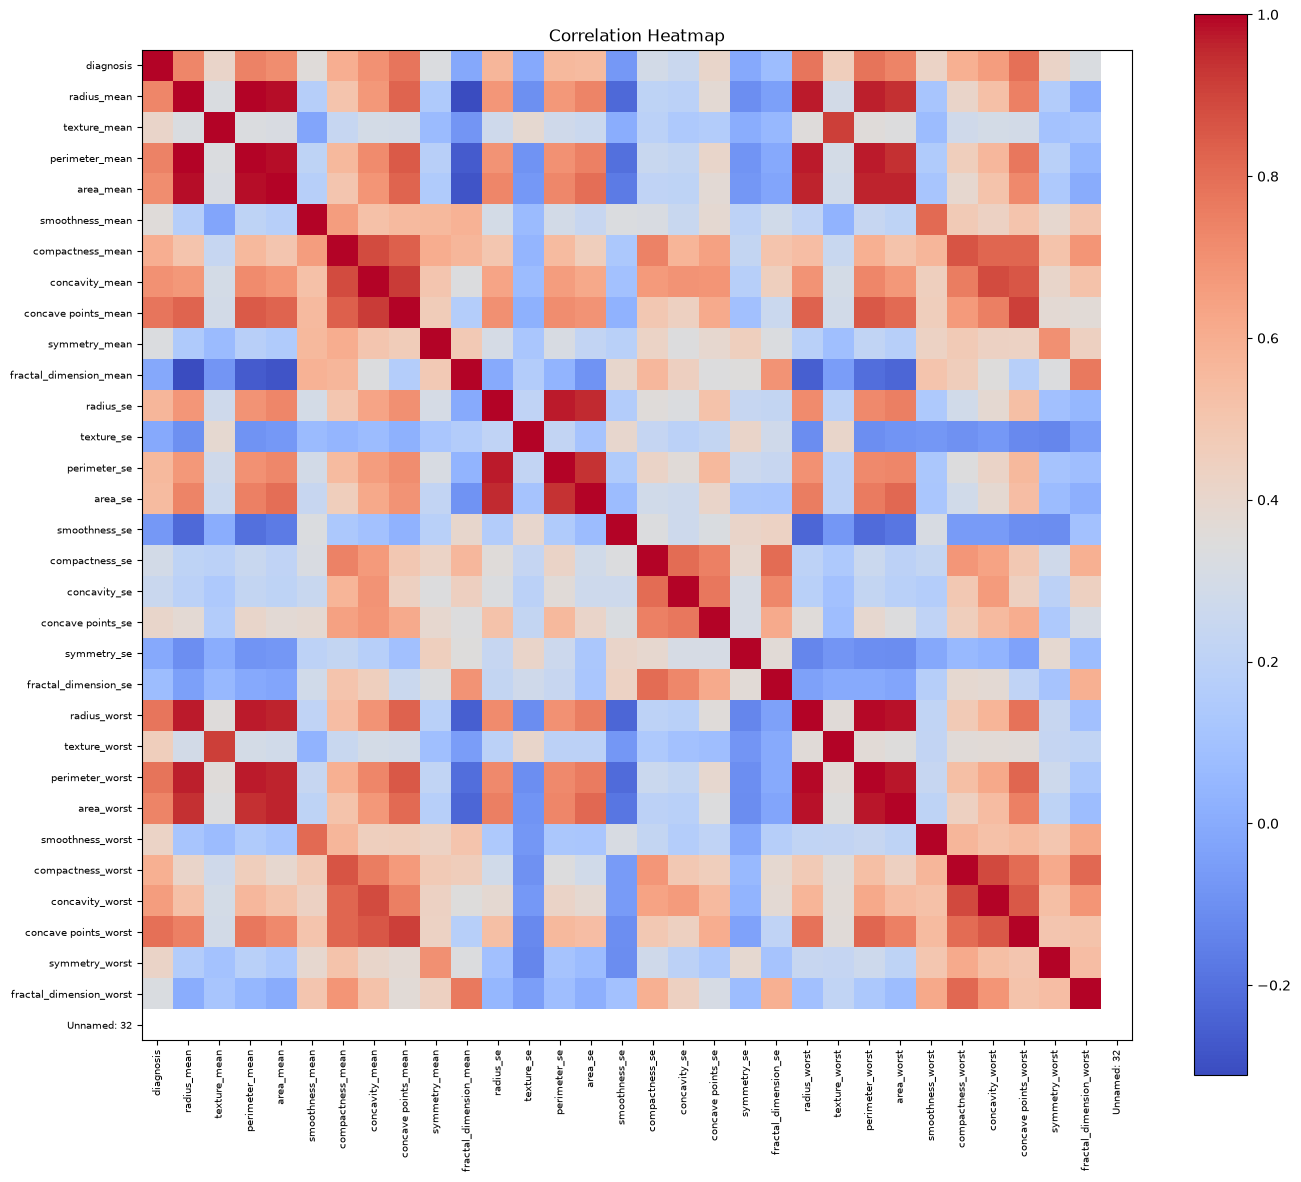

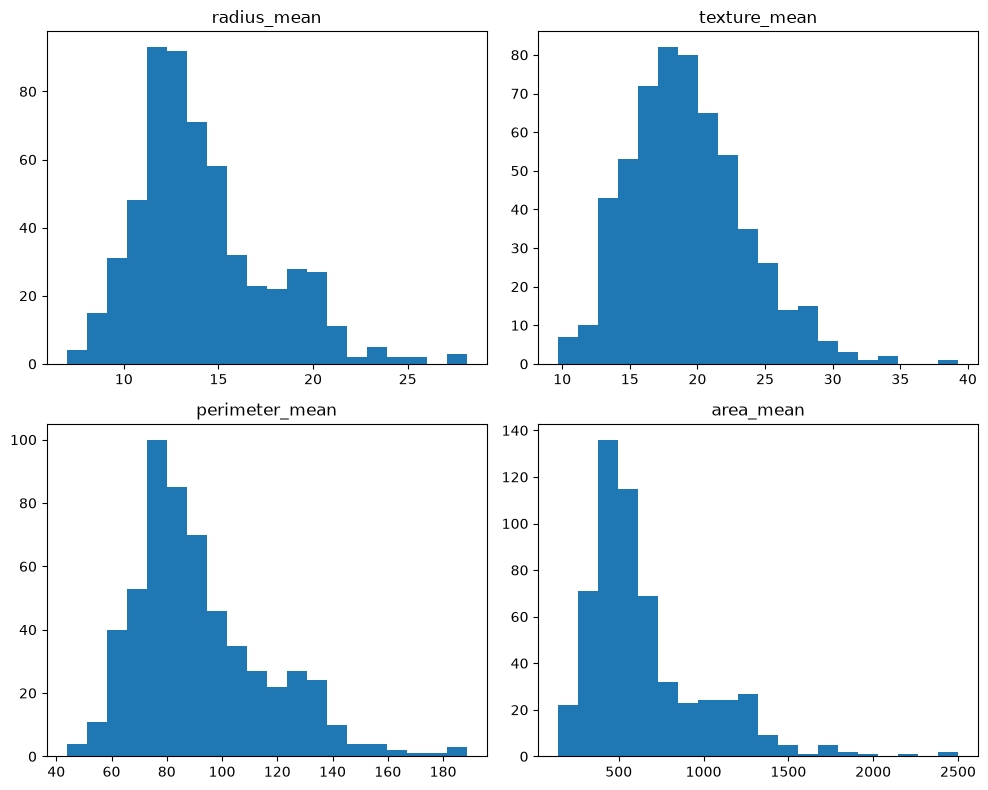


Summary Statistics
        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813   

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

if not os.path.exists("Figures"):
    os.makedirs("Figures")

df = pd.read_csv("breast_cancer_dataset.csv")

df.columns = df.columns.str.strip()

if "id" in df.columns:
    df = df.drop("id", axis=1)

df["diagnosis"] = (
    df["diagnosis"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"M": 1, "B": 0})
)

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nMissing Values")
print(df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())
print("\nDiagnosis Distribution")
print(df["diagnosis"].value_counts())

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=7
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("Figures/correlation_heatmap.png", dpi=300)
plt.show()

selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

plt.figure(figsize=(10, 8))

for i, feature in enumerate(selected_features):
    plt.subplot(2, 2, i + 1)
    plt.hist(df[feature], bins=20)
    plt.title(feature)

plt.tight_layout()
plt.savefig("Figures/feature_distribution.png", dpi=300)
plt.show()

print("\nSummary Statistics")
print(df.describe())

print("\nPart 1 Completed Successfully")


========== BASIC CART ==========

Training Accuracy : 1.0
Testing Accuracy  : 0.9298
Cross Validation  : 0.9209

Tree Depth : 8
Number of Leaves : 24
Number of Nodes : 47

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



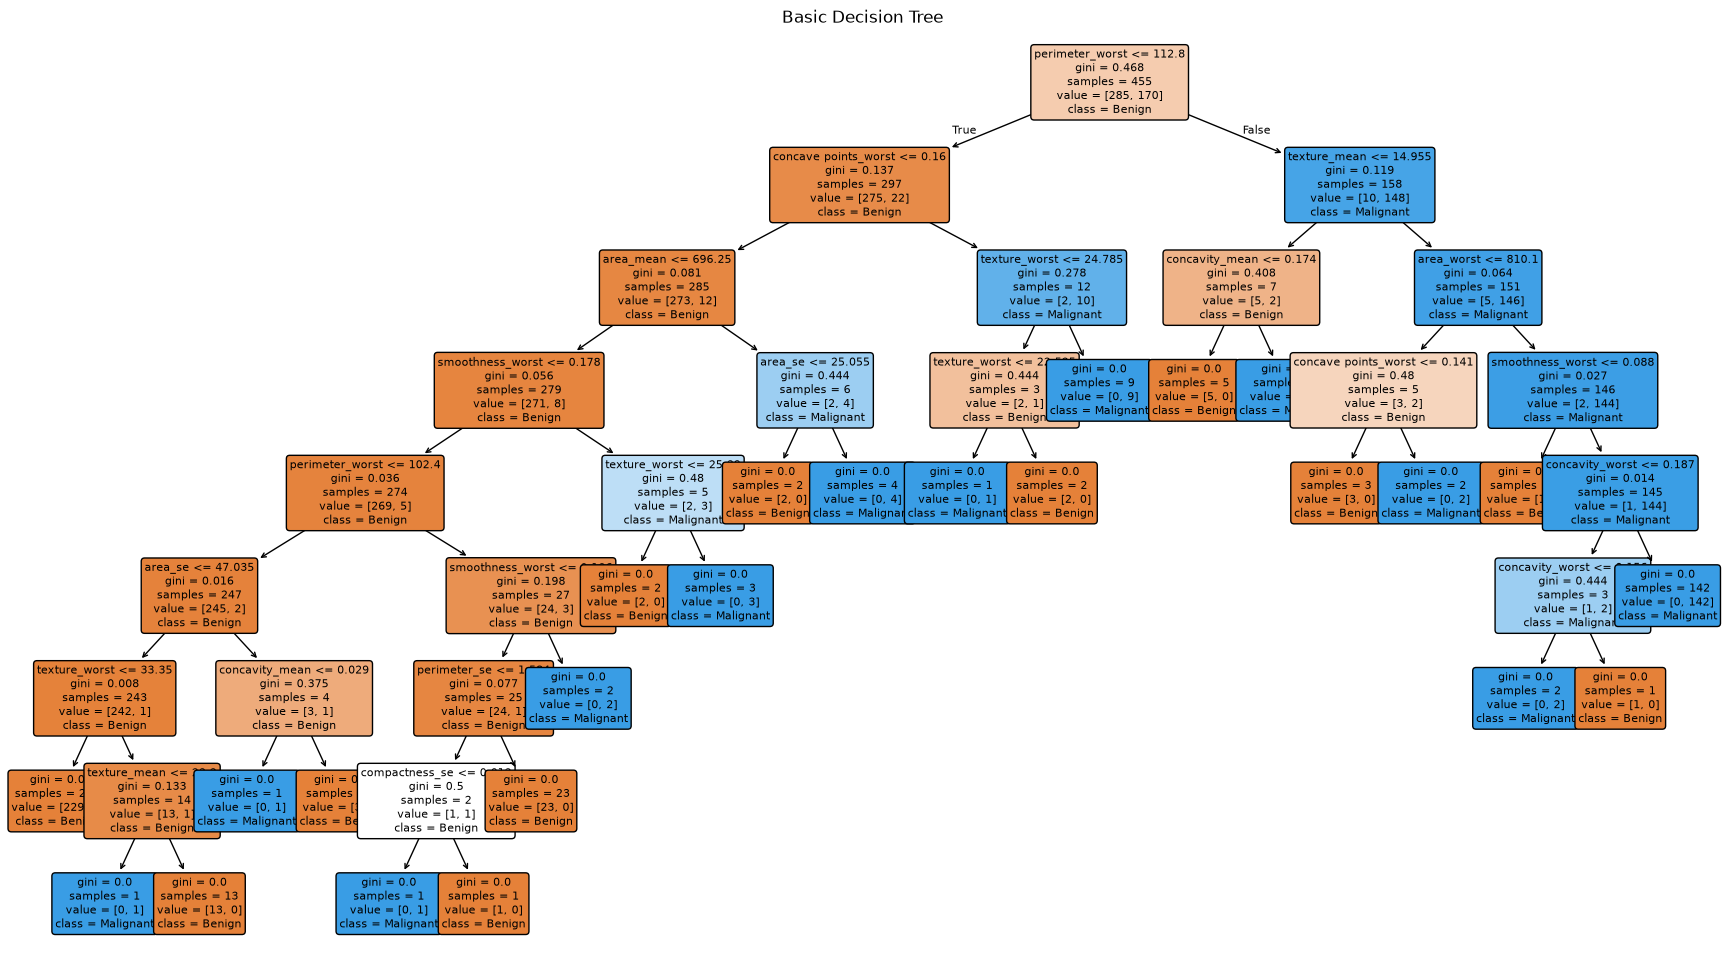


Decision Tree saved successfully.

Part 2 Completed Successfully


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

cart.fit(X_train, y_train)

y_train_pred = cart.predict(X_train)
y_test_pred = cart.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

cv_scores = cross_val_score(
    cart,
    X,
    y,
    cv=5
)

print("\n========== BASIC CART ==========")

print("\nTraining Accuracy :", round(train_accuracy,4))
print("Testing Accuracy  :", round(test_accuracy,4))
print("Cross Validation  :", round(cv_scores.mean(),4))

print("\nTree Depth :", cart.get_depth())
print("Number of Leaves :", cart.get_n_leaves())
print("Number of Nodes :", cart.tree_.node_count)

print("\nClassification Report\n")
print(classification_report(y_test, y_test_pred))

plt.figure(figsize=(22,12))

plot_tree(
    cart,
    feature_names=X.columns,
    class_names=["Benign","Malignant"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Basic Decision Tree")

plt.savefig(
    "Figures/decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nDecision Tree saved successfully.")

basic_train_accuracy = train_accuracy
basic_test_accuracy = test_accuracy
basic_cv_accuracy = cv_scores.mean()
basic_predictions = y_test_pred

print("\nPart 2 Completed Successfully")


Best Parameters
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}

========== TUNED CART ==========

Training Accuracy : 0.967
Testing Accuracy  : 0.9737
Cross Validation  : 0.9385

Tree Depth : 5
Leaves : 8
Nodes : 15

Classification Report

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



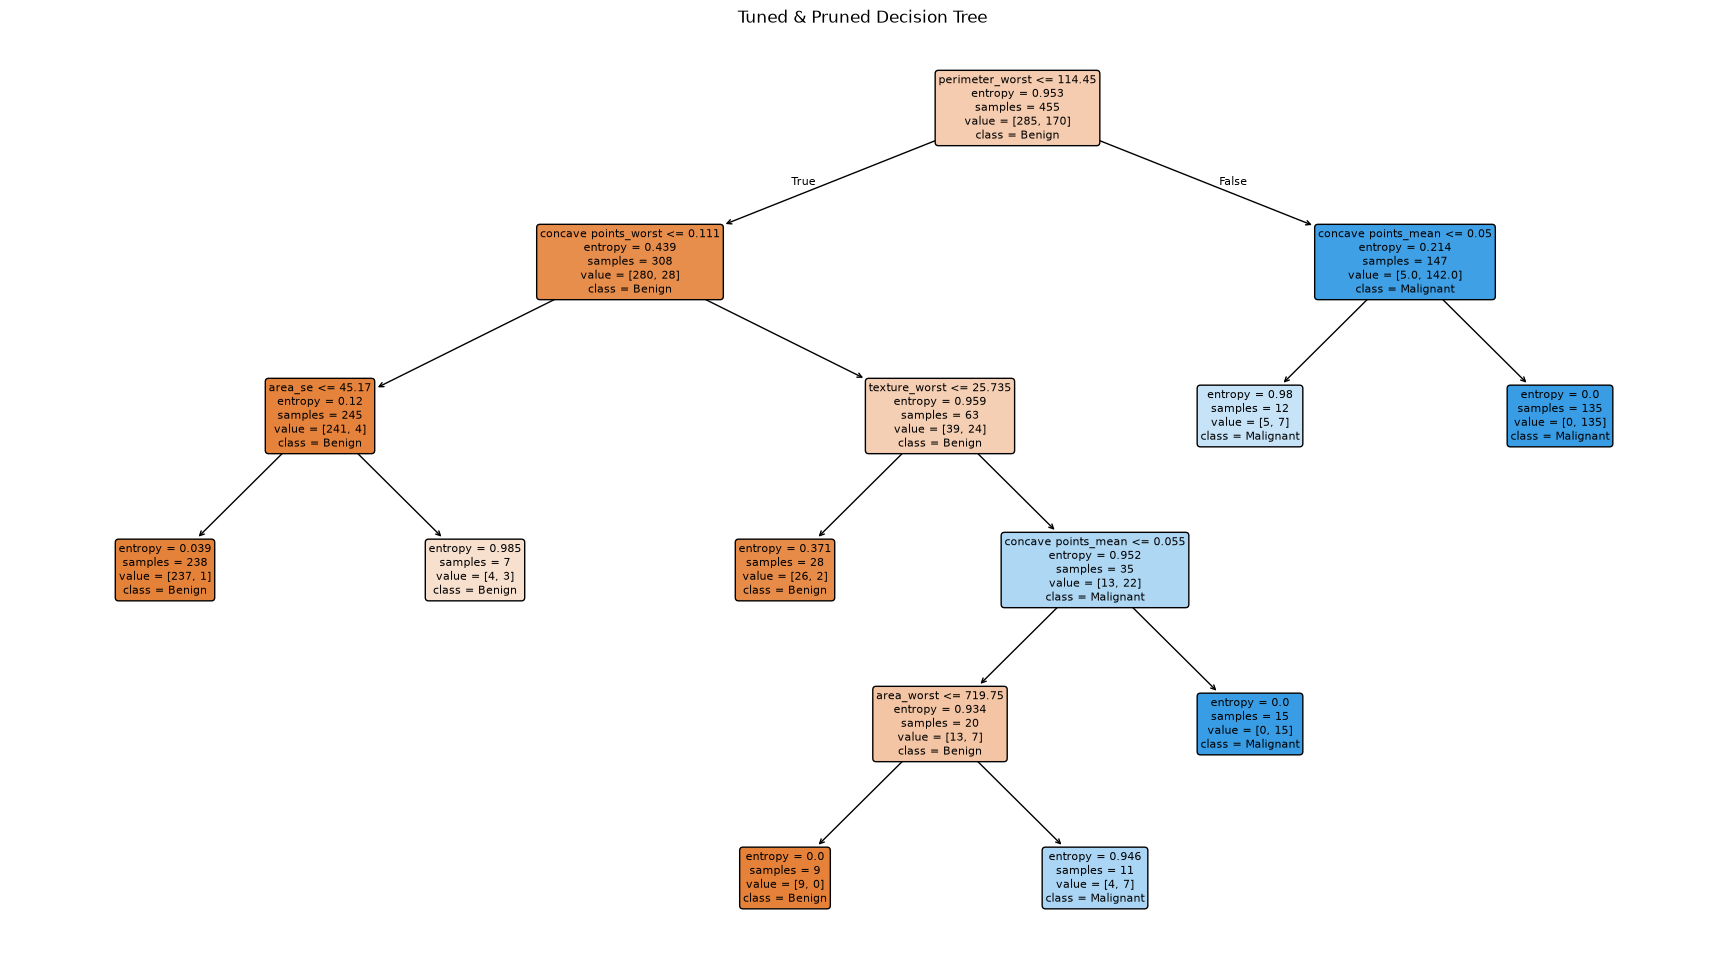

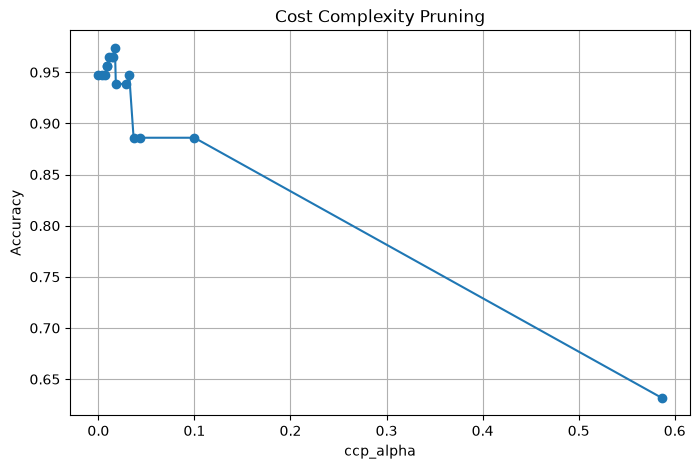


Part 3 Completed Successfully


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Parameters")
print(grid.best_params_)

best_tree = grid.best_estimator_

path = best_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        criterion=grid.best_params_["criterion"],
        max_depth=grid.best_params_["max_depth"],
        min_samples_split=grid.best_params_["min_samples_split"],
        min_samples_leaf=grid.best_params_["min_samples_leaf"],
        ccp_alpha=alpha
    )

    clf.fit(X_train, y_train)

    scores.append(clf.score(X_test, y_test))

best_alpha = ccp_alphas[scores.index(max(scores))]

tuned_cart = DecisionTreeClassifier(
    random_state=42,
    criterion=grid.best_params_["criterion"],
    max_depth=grid.best_params_["max_depth"],
    min_samples_split=grid.best_params_["min_samples_split"],
    min_samples_leaf=grid.best_params_["min_samples_leaf"],
    ccp_alpha=best_alpha
)

tuned_cart.fit(X_train, y_train)

y_pred = tuned_cart.predict(X_test)

train_accuracy = tuned_cart.score(X_train, y_train)
test_accuracy = tuned_cart.score(X_test, y_test)

cv_scores = cross_val_score(
    tuned_cart,
    X,
    y,
    cv=5
)

print("\n========== TUNED CART ==========")

print("\nTraining Accuracy :", round(train_accuracy,4))
print("Testing Accuracy  :", round(test_accuracy,4))
print("Cross Validation  :", round(cv_scores.mean(),4))

print("\nTree Depth :", tuned_cart.get_depth())
print("Leaves :", tuned_cart.get_n_leaves())
print("Nodes :", tuned_cart.tree_.node_count)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(22,12))

plot_tree(
    tuned_cart,
    feature_names=X.columns,
    class_names=["Benign","Malignant"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Tuned & Pruned Decision Tree")

plt.savefig(
    "Figures/tuned_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    ccp_alphas,
    scores,
    marker="o"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Cost Complexity Pruning")

plt.grid(True)

plt.savefig(
    "Figures/pruning_curve.png",
    dpi=300
)

plt.show()

tuned_train_accuracy = train_accuracy
tuned_test_accuracy = test_accuracy
tuned_cv_accuracy = cv_scores.mean()

print("\nPart 3 Completed Successfully")


========== RANDOM FOREST ==========

Training Accuracy : 1.0
Testing Accuracy  : 0.9649
Cross Validation  : 0.9614

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



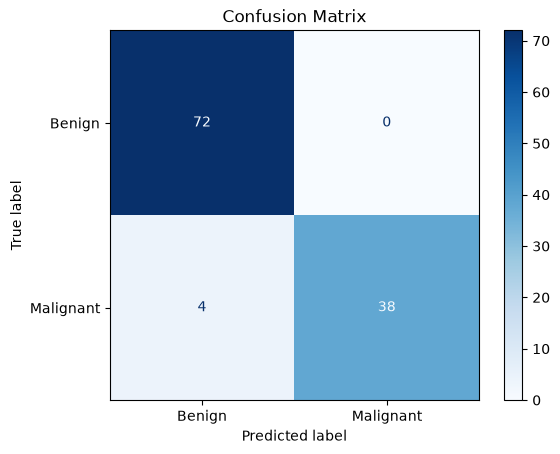

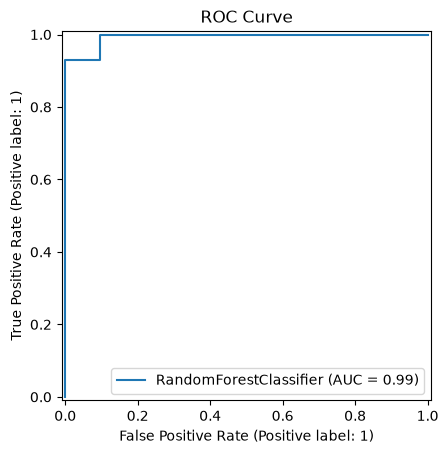

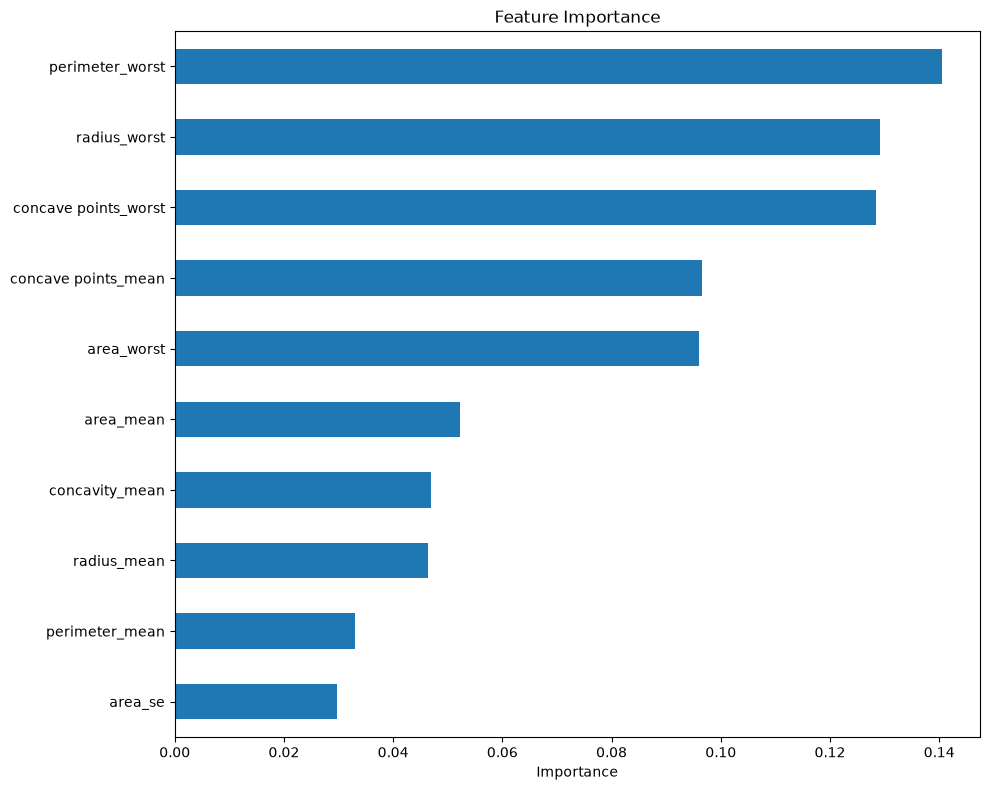

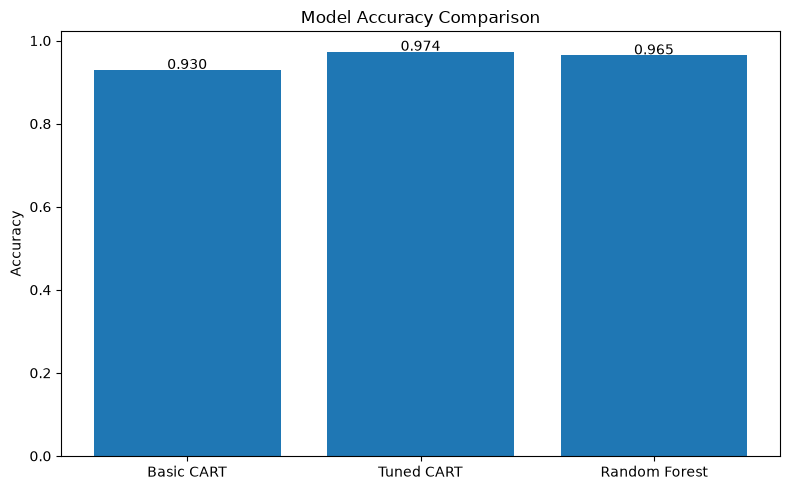


========== FINAL RESULTS ==========

Basic CART Accuracy      : 0.9298
Tuned CART Accuracy      : 0.9737
Random Forest Accuracy   : 0.9649

Generated Figures
Figures/correlation_heatmap.png
Figures/feature_distribution.png
Figures/decision_tree.png
Figures/confusion_matrix.png
Figures/roc_curve.png
Figures/feature_importance.png
Figures/accuracy_comparison.png

Project Completed Successfully.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("\n========== RANDOM FOREST ==========")

print("\nTraining Accuracy :", round(rf_train_accuracy,4))
print("Testing Accuracy  :", round(rf_test_accuracy,4))
print("Cross Validation  :", round(rf_cv.mean(),4))

print("\nClassification Report\n")
print(classification_report(y_test, rf_test_pred))

cm = confusion_matrix(y_test, rf_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign","Malignant"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "Figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.savefig(
    "Figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(10).sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    "Figures/feature_importance.png",
    dpi=300
)

plt.show()

models = [
    "Basic CART",
    "Tuned CART",
    "Random Forest"
]

accuracies = [
    basic_test_accuracy,
    tuned_test_accuracy,
    rf_test_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.tight_layout()

plt.savefig(
    "Figures/accuracy_comparison.png",
    dpi=300
)

plt.show()

print("\n========== FINAL RESULTS ==========")

print("\nBasic CART Accuracy      :", round(basic_test_accuracy,4))
print("Tuned CART Accuracy      :", round(tuned_test_accuracy,4))
print("Random Forest Accuracy   :", round(rf_test_accuracy,4))

print("\nGenerated Figures")

print("Figures/correlation_heatmap.png")
print("Figures/feature_distribution.png")
print("Figures/decision_tree.png")
print("Figures/confusion_matrix.png")
print("Figures/roc_curve.png")
print("Figures/feature_importance.png")
print("Figures/accuracy_comparison.png")

print("\nProject Completed Successfully.")